# Wind Turbine SCADA Data Analysis  
## **Author:** *Owen Nda Diche*


##  Introduction  

This project explores a **Wind Turbine SCADA dataset**, which contains high-frequency measurements of turbine operation such as active power output, wind speed, theoretical power curve and wind direction.

SCADA (Supervisory Control and Data Acquisition) systems are widely used in wind farms to monitor performance and detect issues. By analysing SCADA data, we can understand turbine behaviour, evaluate performance relative to the theoretical power curve, and identify potential under-performance or anomalous operation.

This notebook focuses on exploratory data analysis and visualisation and lays the foundation for future work such as performance assessment, anomaly detection and predictive modelling.


## Objectives  

In this notebook, I will:

- Load and preprocess the wind turbine SCADA dataset  
- Explore the structure and basic statistics of the measurements  
- Visualise relationships between wind speed, actual power and theoretical power  
- Analyse temporal patterns  
- Compare actual output to theoretical curves  
- Generate insights relevant to turbine performance

## Dataset  

Wind Turbine SCADA dataset (Kaggle):  
https://www.kaggle.com/datasets/berkerisen/wind-turbine-scada-dataset



In [2]:
# Imports and configuration

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")



## Load the dataset
Reads the SCADA CSV file.



In [3]:
df = pd.read_csv("wind_turbine_scada.csv")
df.head(), df.shape


(          Date/Time  LV ActivePower (kW)  Wind Speed (m/s)  \
 0  01 01 2018 00:00           380.047791          5.311336   
 1  01 01 2018 00:10           453.769196          5.672167   
 2  01 01 2018 00:20           306.376587          5.216037   
 3  01 01 2018 00:30           419.645905          5.659674   
 4  01 01 2018 00:40           380.650696          5.577941   
 
    Theoretical_Power_Curve (KWh)  Wind Direction (°)  
 0                     416.328908          259.994904  
 1                     519.917511          268.641113  
 2                     390.900016          272.564789  
 3                     516.127569          271.258087  
 4                     491.702972          265.674286  ,
 (50530, 5))

## Inspect structure & columns
Display columns, datatypes and missing values.



In [4]:
print("Shape:", df.shape)
print("\nColumns:\n", df.columns.tolist())

print("\nData types:\n", df.dtypes)

print("\nMissing values:\n",
      df.isnull().sum().sort_values(ascending=False).head(10))


Shape: (50530, 5)

Columns:
 ['Date/Time', 'LV ActivePower (kW)', 'Wind Speed (m/s)', 'Theoretical_Power_Curve (KWh)', 'Wind Direction (°)']

Data types:
 Date/Time                         object
LV ActivePower (kW)              float64
Wind Speed (m/s)                 float64
Theoretical_Power_Curve (KWh)    float64
Wind Direction (°)               float64
dtype: object

Missing values:
 Date/Time                        0
LV ActivePower (kW)              0
Wind Speed (m/s)                 0
Theoretical_Power_Curve (KWh)    0
Wind Direction (°)               0
dtype: int64


## Rename key columns
 Standardises column names.



In [5]:
column_map = {}

for col in df.columns:
    low = col.lower()
    if "date" in low and "time" in low:
        column_map[col] = "datetime"
    elif "activepower" in low:
        column_map[col] = "active_power_kw"
    elif "wind speed" in low:
        column_map[col] = "wind_speed_ms"
    elif "theoretical_power" in low:
        column_map[col] = "theoretical_power_kw"
    elif "wind direction" in low:
        column_map[col] = "wind_direction_deg"

df = df.rename(columns=column_map)

df.columns


Index(['datetime', 'active_power_kw', 'wind_speed_ms', 'theoretical_power_kw',
       'wind_direction_deg'],
      dtype='object')

## Convert data types & clean

In [7]:
# Convert datetime
if "datetime" in df.columns:
    df["datetime"] = pd.to_datetime(df["datetime"], errors="coerce")

# Convert numeric
numeric_cols = [
    col for col in ["active_power_kw","wind_speed_ms",
                    "theoretical_power_kw","wind_direction_deg"]
    if col in df.columns
]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Drop rows missing datetime
if "datetime" in df.columns:
    df = df.dropna(subset=["datetime"])

df.head()


,datetime,active_power_kw,wind_speed_ms,theoretical_power_kw,wind_direction_deg
0,2018-01-01 00:00:00,380.047791,5.311336,416.328908,259.994904
1,2018-01-01 00:10:00,453.769196,5.672167,519.917511,268.641113
2,2018-01-01 00:20:00,306.376587,5.216037,390.900016,272.564789
3,2018-01-01 00:30:00,419.645905,5.659674,516.127569,271.258087
4,2018-01-01 00:40:00,380.650696,5.577941,491.702972,265.674286



##  Basic descriptive statistics



In [8]:
df[numeric_cols].describe()


,active_power_kw,wind_speed_ms,theoretical_power_kw,wind_direction_deg
count,19986.000000,19986.000000,19986.000000,19986.000000
mean,1288.909926,7.426596,1431.806250,123.394620
std,1331.469603,4.413426,1393.029151,91.891811
min,-0.959000,0.000000,0.000000,0.000000
25%,37.647800,3.902067,109.964169,52.769822
50%,744.524994,6.716754,893.422809,73.963028
75%,2514.793762,10.345635,2988.946385,202.124226
max,3605.758057,25.206011,3600.000000,359.977295



## Set datetime index



In [10]:
if "datetime" in df.columns:
    df = df.sort_values("datetime").set_index("datetime")

df.head()


,active_power_kw,wind_speed_ms,theoretical_power_kw,wind_direction_deg
datetime,,,,
2018-01-01 00:00:00,380.047791,5.311336,416.328908,259.994904
2018-01-01 00:10:00,453.769196,5.672167,519.917511,268.641113
2018-01-01 00:20:00,306.376587,5.216037,390.900016,272.564789
2018-01-01 00:30:00,419.645905,5.659674,516.127569,271.258087
2018-01-01 00:40:00,380.650696,5.577941,491.702972,265.674286



## Time-series visualisation



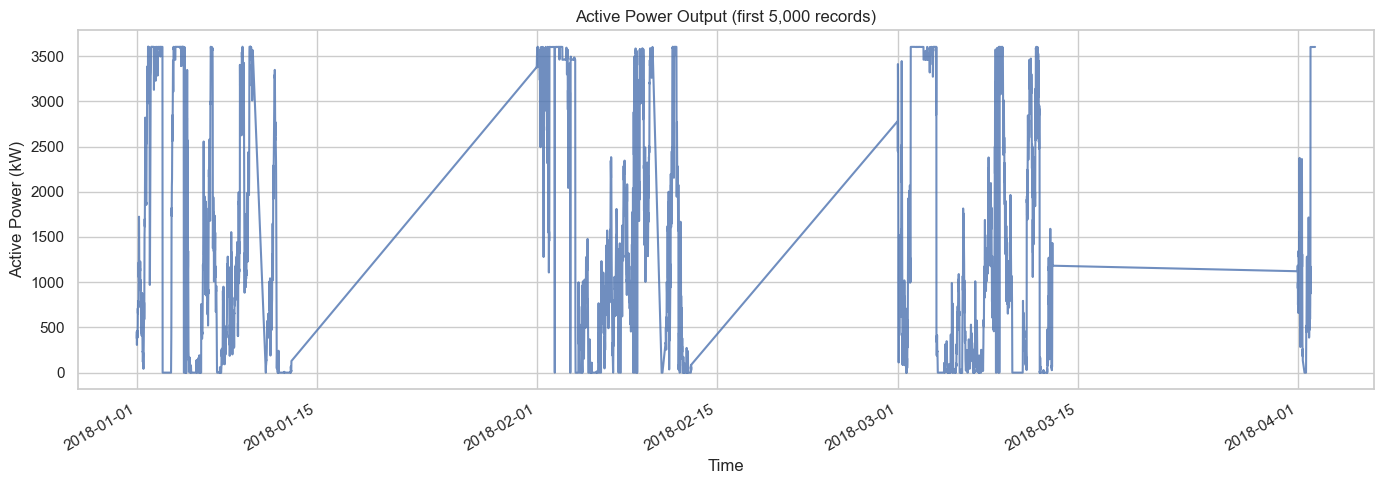

In [11]:
plt.figure(figsize=(14,5))
df["active_power_kw"].iloc[:5000].plot(alpha=0.8)
plt.title("Active Power Output (first 5,000 records)")
plt.ylabel("Active Power (kW)")
plt.xlabel("Time")
plt.tight_layout()
plt.show()



## Wind speed vs active power



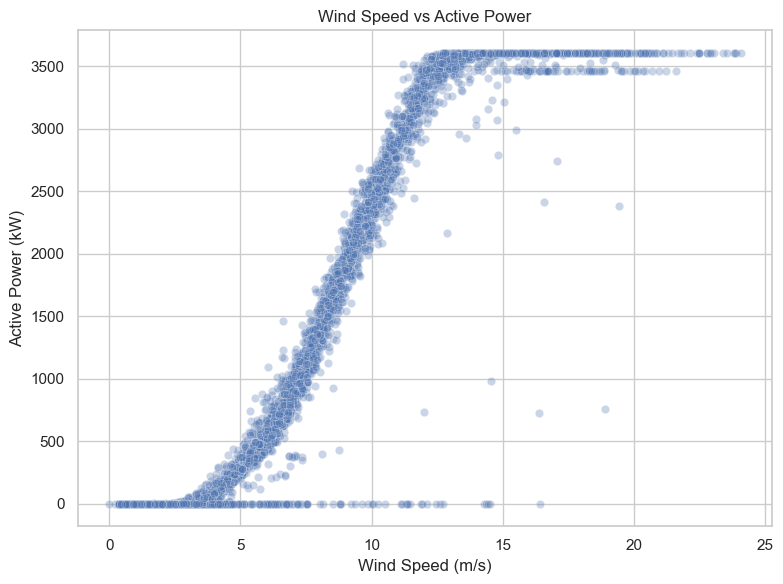

In [12]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df.sample(min(5000, len(df))),
    x="wind_speed_ms",
    y="active_power_kw",
    alpha=0.3
)
plt.title("Wind Speed vs Active Power")
plt.xlabel("Wind Speed (m/s)")
plt.ylabel("Active Power (kW)")
plt.tight_layout()
plt.show()



## Actual vs theoretical power curve


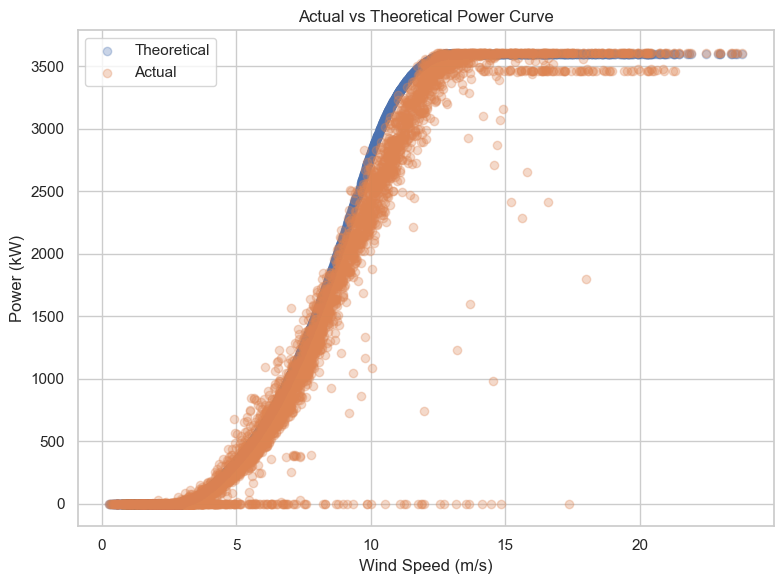

In [14]:
if "theoretical_power_kw" in df.columns:
    plt.figure(figsize=(8,6))
    sample = df.sample(min(5000, len(df)))
    plt.scatter(sample["wind_speed_ms"],
                sample["theoretical_power_kw"], alpha=0.3, label="Theoretical")
    plt.scatter(sample["wind_speed_ms"],
                sample["active_power_kw"], alpha=0.3, label="Actual")
    plt.title("Actual vs Theoretical Power Curve")
    plt.xlabel("Wind Speed (m/s)")
    plt.ylabel("Power (kW)")
    plt.legend()
    plt.tight_layout()
    plt.show()



## Daily & monthly trends



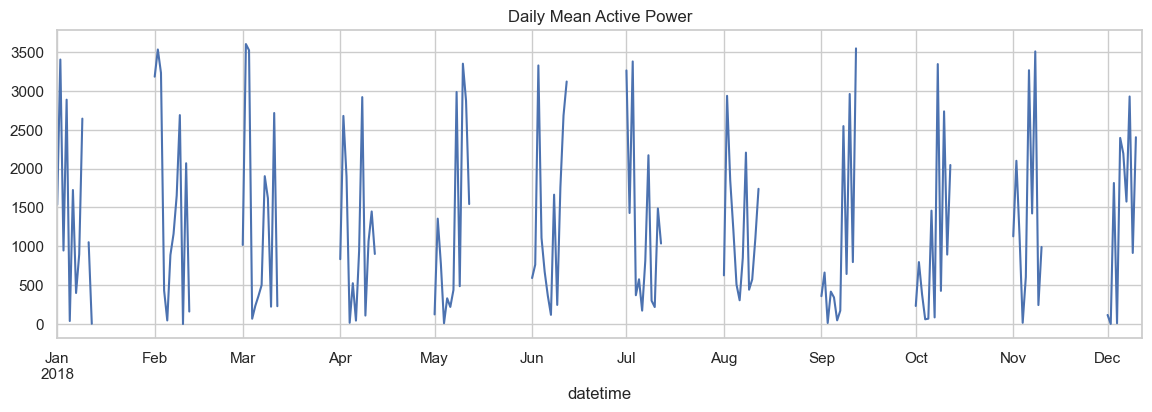

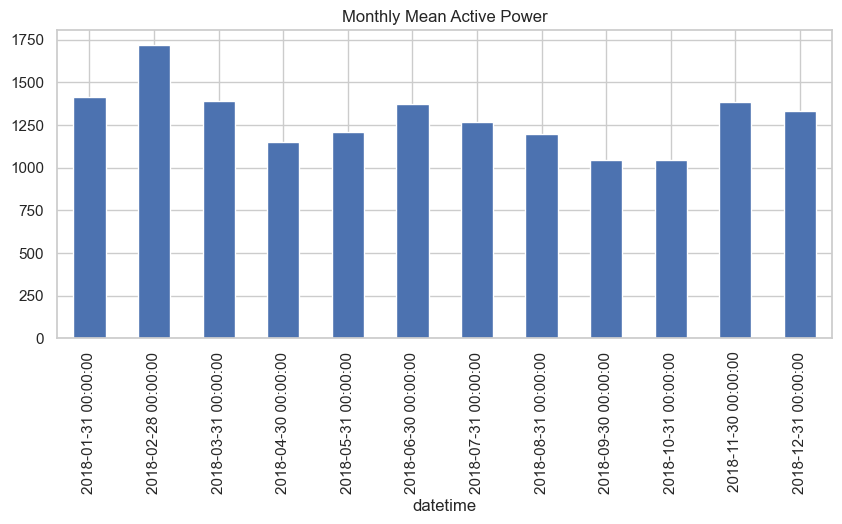

In [17]:
if "active_power_kw" in df.columns:
    daily_mean = df["active_power_kw"].resample("D").mean()
    monthly_mean = df["active_power_kw"].resample("ME").mean()

    daily_mean.plot(figsize=(14,4), title="Daily Mean Active Power")
    plt.show()

    monthly_mean.plot(kind="bar", figsize=(10,4), title="Monthly Mean Active Power")
    plt.show()



## Wind direction analysis



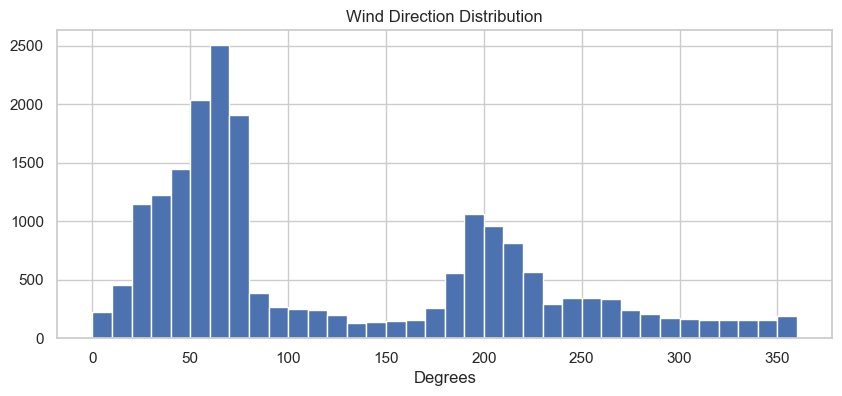

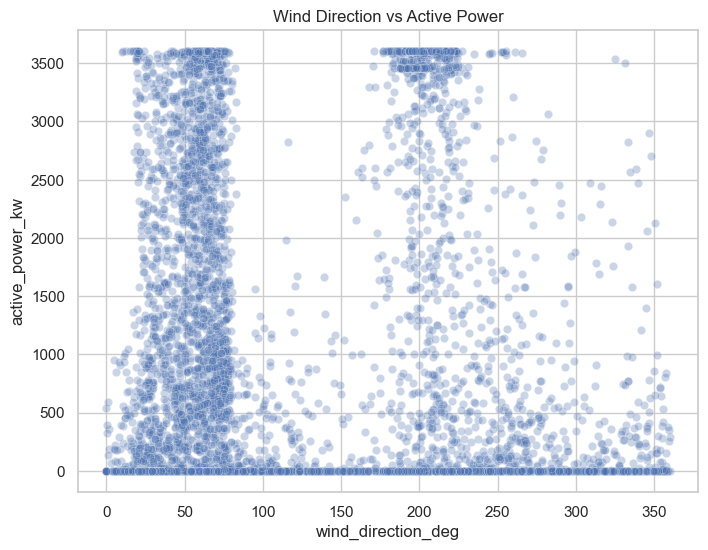

In [18]:
if "wind_direction_deg" in df.columns:
    plt.figure(figsize=(10,4))
    df["wind_direction_deg"].hist(bins=36)
    plt.title("Wind Direction Distribution")
    plt.xlabel("Degrees")
    plt.show()

    plt.figure(figsize=(8,6))
    sns.scatterplot(
        data=df.sample(min(5000, len(df))),
        x="wind_direction_deg",
        y="active_power_kw",
        alpha=0.3
    )
    plt.title("Wind Direction vs Active Power")
    plt.show()


## Simple anomaly indicator 


10.002001400980687 % underperforming


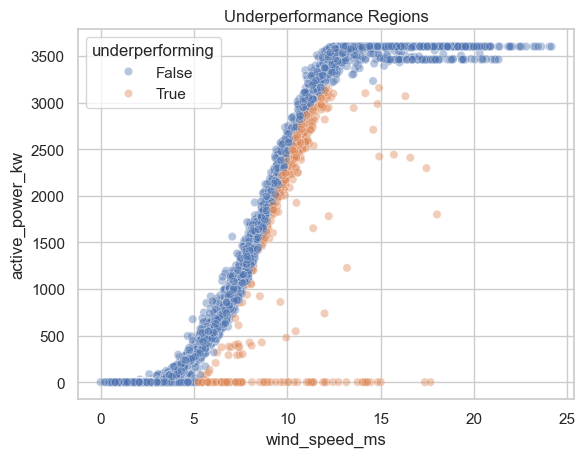

In [19]:
if {"active_power_kw","theoretical_power_kw"}.issubset(df.columns):
    df["power_gap_kw"] = df["theoretical_power_kw"] - df["active_power_kw"]
    df["underperforming"] = df["power_gap_kw"] > df["power_gap_kw"].quantile(0.9)

    print(df["underperforming"].mean()*100, "% underperforming")

    sns.scatterplot(
        data=df.sample(min(5000, len(df))),
        x="wind_speed_ms",
        y="active_power_kw",
        hue="underperforming",
        alpha=0.4
    )
    plt.title("Underperformance Regions")
    plt.show()



##  Save cleaned dataset



In [20]:
df.to_csv("wind_turbine_scada_clean.csv")



##  Insights  

- Power increases with wind speed until a saturation point  
- Actual vs theoretical comparison suggests generally good performance  
- Some underperformance detected at certain wind-speed intervals  
- Seasonal trends indicate higher output during windy periods  


## What this notebook demonstrates  

- Real SCADA supervisory energy data  
- Exploratory data analysis  
- Power curve interpretation  
- Time-series visualisation  
- Anomaly indicators  


